In [22]:
def euler(pos, vel, h):
    return pos[-1] + (h * vel[-1])

In [23]:
def adams_2(pos, vel, h):
    return pos[-1] + (h * (1.5* vel[-1] - 0.5 * vel[-2] ))

In [24]:
from typing import List, TypeVar, Callable
import sympy as sp
import numpy as np

# Use a generic TypeVar for flexible state types (e.g., float, np.ndarray)
T = TypeVar('T', float, np.ndarray)

def get_ab_coefficients(s: int) -> List[float]:
    """
    Helper function to generate floating-point coefficients 
    for an s-step Adams-Bashforth method.
    """
    u = sp.Symbol('u')
    coeffs = []
    for j in range(s):
        num, den = 1, 1
        for m in range(s):
            if m != j:
                num *= (u + m)
                den *= (m - j)
        # Convert the symbolic fraction to a standard Python float
        val = float(sp.integrate(num / den, (u, 0, 1)))
        coeffs.append(val)
    return coeffs


def adams_bashforth(
    pos_history: List[T], 
    vel_history: List[T], 
    h: float, 
    requested_order: int
) -> T:
    """
    Computes the next position state using an explicit Adams-Bashforth multi-step method.
    
    Parameters:
        pos_history: List of past positions [..., y_{n-2}, y_{n-1}, y_n]
        vel_history: List of past velocities/derivatives [..., f_{n-2}, f_{n-1}, f_n]
        h:           Time step size
        requested_order: The desired maximum multi-step order (s)
        
    Returns:
        The updated position at the next time step, y_{n+1}
    """
    # 1. Determine the actual order we can use based on available history
    available_steps = len(vel_history)
    current_order = min(requested_order, available_steps)
    
    if current_order == 0:
        raise ValueError("History lists cannot be empty.")

    # 2. Extract the exact number of past velocity states required for this order.
    # We slice from the right side of the list to get the most recent data points.
    # relevant_vels will be ordered: [f_{n-s+1}, ..., f_{n-1}, f_n]
    relevant_vels = vel_history[-current_order:]
    
    # 3. Generate the universal coefficients for this order
    coeffs = get_ab_coefficients(current_order)
    
    # 4. Apply the Adams-Bashforth summation formula:
    # y_{n+1} = y_n + h * (beta_0 * f_n + beta_1 * f_{n-1} + ... + beta_{s-1} * f_{n-s+1})
    # Note: Our math derivation mapped beta_0 to f_n, beta_1 to f_{n-1}.
    # Since relevant_vels is sorted oldest-to-newest, we reverse the coefficients 
    # to align them properly during compilation.
    coeffs_reversed = list(reversed(coeffs))
    
    weighted_sum = sum(c * f for c, f in zip(coeffs_reversed, relevant_vels))
    
    # y_n is always the absolute last element in our position history
    y_n = pos_history[-1]
    
    return y_n + h * weighted_sum

# Test: projectile

In [25]:
import numpy as np
import matplotlib.pyplot as plt

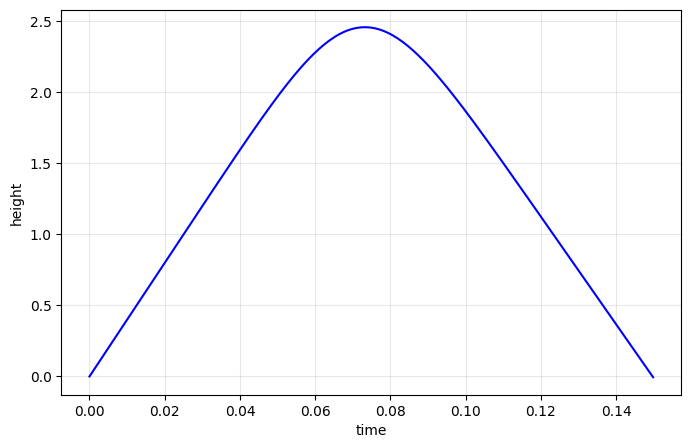

In [ ]:
step = 7e-4

pos = []
vel = []
acc = []

times = []
times.append( 0 )

pos_i = 0.0
vel_i = 40.0
pos.append(pos_i)
vel.append(vel_i)

def g_force(x):
    return -9.81 * x**6

while pos[-1] >= 0:
    acc.append( g_force(pos[-1]) )
    if len(pos) < 2 :
    # if True:
        vel.append( euler(vel, acc, step) )
        pos.append( euler(pos, vel, step) )
    else:
        vel.append( adams_2(vel, acc, step) )
        pos.append( adams_2(pos, vel, step) )

    times.append( times[-1] + step )

plt.figure(figsize=(8, 5))
plt.plot(
    times,
    pos,
    color='blue',
    # label= f'drag: c_d={c_d}, lift: c_l={c_l}'
    )
plt.grid(True, alpha=0.3)
plt.xlabel('time')
plt.ylabel('height')
plt.show()

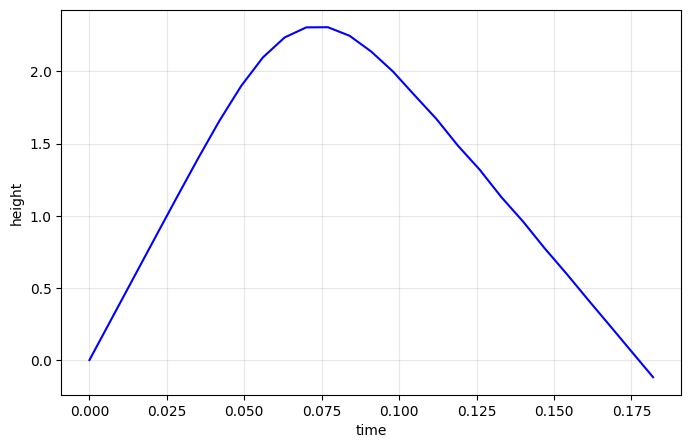

In [32]:
step = 7e-3

pos = []
vel = []
acc = []

times = []
times.append( 0 )

pos_i = 0.0
vel_i = 40.0
pos.append(pos_i)
vel.append(vel_i)

def g_force(x):
    return -9.81 * x**6

while pos[-1] >= 0:
    acc.append( g_force(pos[-1]) )
    vel.append( adams_bashforth(vel, acc, step, 5) )
    pos.append( adams_bashforth(pos, vel, step, 5) )

    times.append( times[-1] + step )

plt.figure(figsize=(8, 5))
plt.plot(
    times,
    pos,
    color='blue',
    # label= f'drag: c_d={c_d}, lift: c_l={c_l}'
    )
plt.grid(True, alpha=0.3)
plt.xlabel('time')
plt.ylabel('height')
plt.show()